Далее будет сделаны импорты, необходимые для выполнения работы.  В процессе работы иимпорты будут добавляться 

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from pandas.plotting import scatter_matrix

np.random.seed(123)

In [ ]:
ds_original = pd.read_csv("../data/V4.csv", index_col=0)

Работа с исходными данными
=

Описатальная статистика
-

Считаем файл в DataFrame и выведем информацию о нём. Параметр ф-ции read_csv index_col, использовался, что первый столбик сделать индексом(так как это они и есть, если посмотреть на файл).

In [ ]:
ds_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Name        500 non-null    str    
 1   Customer e-mail      500 non-null    str    
 2   Country              500 non-null    str    
 3   Gender               244 non-null    float64
 4   Age                  500 non-null    int64  
 5   Annual Salary        500 non-null    float64
 6   Credit Card Debt     500 non-null    float64
 7   Net Worth            500 non-null    float64
 8   Car Purchase Amount  500 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 35.3 KB


Теперь посмотрим на о как выглядят значения 

In [108]:
ds_original.head()

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0.0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0.0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,NaN,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,NaN,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1.0,57,59729.15130,5358.712177,560304.0671,55915.46248


Тут можно видеть, что некоторые колонки имеют неоптимальный тип данных(например пол - он может быть bool, а не float). Также я уверен, что колонку Country можно отредачить и привести к типу данных int, а также есть сомнительные столбцы для анализа ключевого Car Purchase Amount , как например Customer e-mail. Также я бы воззможно в будущем объединил Annual Salary и Credit Card Debt и Net Worth, чтобы понимать общие финансовые возможности человека.  Выведу статистику для числовых значений.

In [109]:
ds_original.describe()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
count,244.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.500000,46.224000,62127.239608,9607.645049,431475.713625,44209.799218
std,0.501028,7.990339,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,41.000000,54391.977195,7397.515792,299824.195900,37629.896040
50%,0.500000,46.000000,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,52.000000,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


Тут можно заметитть интересную статистику - машины покупают люди всех возрастов от 20 до 70, больше пока не могу сказать ничего интересного. Дальше перейдём вузуализации данных. Построим гистограммы для кадлой колонки. Для кадого параметра буду писать код в отдельном сегменте кода с пояснениями к своим действиям. Визуализации Customer Name, Customer e-mail, потому что эти данные не несут никакой ценноси.

Одномерная визуализация данных
-

Начну с построения гистограммы для стран, чтобы понять в каких странах чаще покупают машины и какие страны в целом есть. Чтобы посчитатать в каких странах сколько покупок сделано, применю функцию value_counts.

In [110]:
countries = ds_original["Country"].value_counts()
print(countries)

Country
USA    500
Name: count, dtype: int64


Как выяснилось, все данные взяты из USA, так что столбец Country можно дальше не анализировать, в также он не имеет ценности для анализа и его можно будет удалить в дальнейшем

Теперь проанализируем столбец Gender, чтобы понять какой пол покупает больше машин. Единственное есть пробоема с тем, что больеш половины данных имеют пустые значения, так что сомневаюсь на сколько можно считать полученный график правдивым в рамках датасета. Также будет использована функция value_count. 

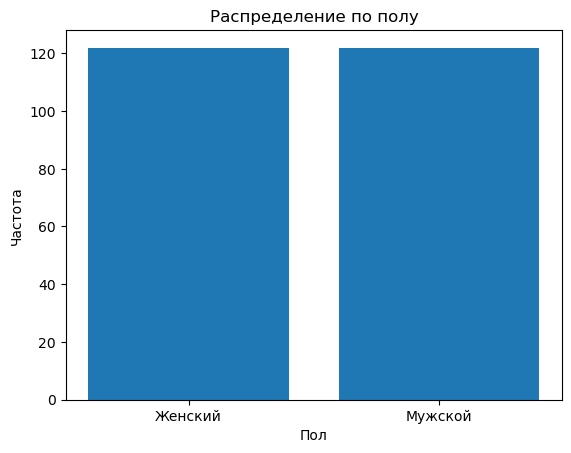

In [111]:
genders_origin = ds_original.Gender.value_counts()

plt.bar(genders_origin.index, genders_origin.values)
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Частота')
plt.xticks([0, 1], ['Женский', 'Мужской'])
plt.show()




Можем видеть, что люди разных полов одинаково часта покупают машины, из этого можно сделать вывод, что все пропущенные значения можно заполнить также 50/50. Это и сделаем.

In [112]:
nan_count = ds_original['Gender'].isna().sum()
fill_values = np.array([0] * 128 + [1] * 128)
np.random.shuffle(fill_values)
ds_original.loc[ds_original['Gender'].isna(), 'Gender'] = fill_values


Дальше перейду к анализу поля Age

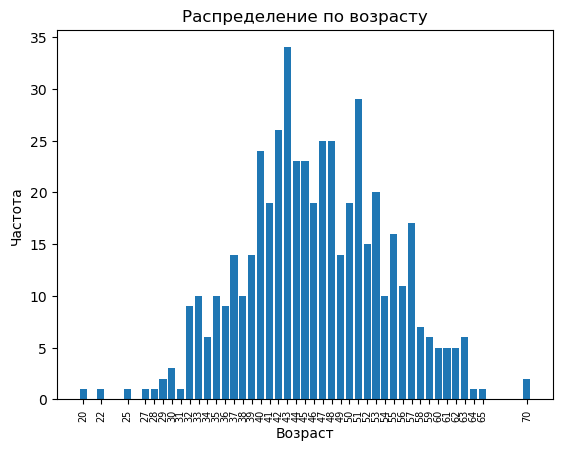

In [113]:
ages_origin = ds_original.Age.value_counts()
plt.bar(ages_origin.index, ages_origin.values)
plt.title("Распределение по возрасту")
plt.xlabel("Возраст")
plt.xticks(ages_origin.index, rotation=90, fontsize=7) 
plt.ylabel("Частота")
plt.show()

На графике видно, что большая часть людей покупает машины в возрасте 43 лет. Так же в целом можно заметить, что в юном и пожилом возрасте люди покупают машины меньше, это можно связать с финансовыми возмностями в этом возрасте и в отсутствии потребности в приобретении новых автомобилей(это скорей про старшие возраста). 

Перейду к анализу Annual_salary

In [114]:
annual_salary_origin = ds_original["Annual Salary"].value_counts()
annual_salary_origin = annual_salary_origin.sort_index()

annual_salary_origin

Annual Salary
20000.00000     1
32697.98161     1
33422.99683     1
34154.77654     1
35069.41886     1
               ..
90556.62686     1
91083.73918     1
92455.72807     1
92471.17612     1
100000.00000    1
Name: count, Length: 500, dtype: int64

Как можно видеть, все значения уникальны и по гистограмме оценить распределение нельзя. Я предлагаю объединить значения по десяткам тысяч, то есть первый столбец все 2х_ххх, второй 3х_ххх и т.д. Это поможет примерно поять распределение годовых зарпалт людей и построить по этим данным гистограмму.

In [115]:
a = 1000
bins = range(20000, 100000, a)
labels = [str(x) for x in bins[:-1]]

annual_salary_grouped_origins =  pd.cut(annual_salary_origin.index,  bins=bins, labels=labels).value_counts()


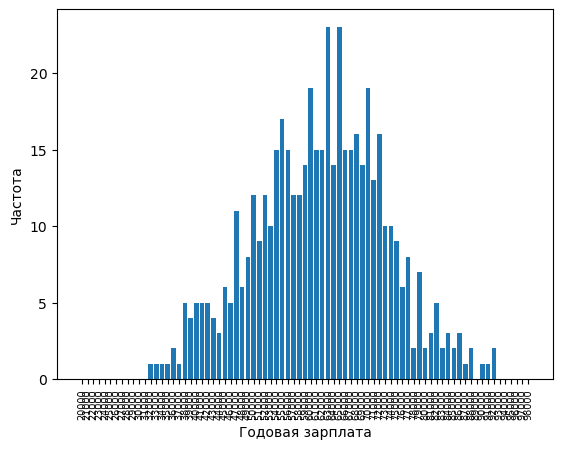

In [116]:
plt.bar(annual_salary_grouped_origins.index, annual_salary_grouped_origins.values)
plt.xlabel("Годовая зарплата")
plt.ylabel("Частота")
plt.xticks(annual_salary_grouped_origins.index, rotation=90, fontsize=7)
plt.show()


На изображении мы можем сделать вывод, что распределение стремится к нормальному и больше всего получают зарплату в размере 60000. 

Далее перейдём к Credit Card Debt, действия будут аналогичные. Только теперь будем использовать функцию cut

In [117]:
credit_card_debt_origin = ds_original["Credit Card Debt"].value_counts()
credit_card_debt_origin = credit_card_debt_origin.sort_index()

credit_card_debt_origin

Credit Card Debt
100.000000      1
594.804949      1
632.052852      1
640.045378      1
861.816653      1
               ..
17870.637650    1
18361.249150    1
18693.146520    1
19692.912620    1
20000.000000    1
Name: count, Length: 500, dtype: int64

In [118]:
a = 500
bins = range(100, 20100, a)
labels = [str(x) for x in bins[:-1]]

credit_card_debt_grouped_origin = pd.cut(credit_card_debt_origin.index,  bins=bins, labels=labels).value_counts()

credit_card_debt_grouped_origin

100       1
600       6
1100      0
1600      4
2100      3
2600      5
3100      3
3600      7
4100      8
4600     14
5100      9
5600     14
6100     16
6600     22
7100     23
7600     29
8100     22
8600     29
9100     28
9600     35
10100    23
10600    32
11100    31
11600    23
12100    18
12600    15
13100    15
13600    15
14100    14
14600     7
15100     8
15600     4
16100     4
16600     3
17100     3
17600     2
18100     1
18600     1
19100     0
Name: count, dtype: int64

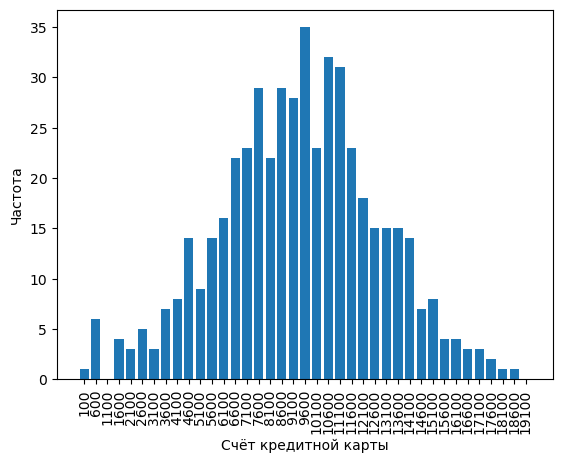

In [119]:
plt.bar(credit_card_debt_grouped_origin.index, credit_card_debt_grouped_origin.values)
plt.xlabel("Счёт кредитной карты")
plt.ylabel("Частота")
plt.xticks( rotation=90) 
plt.show()


Опять видно, что распределение стремится к нормальному и большая часть значений сосредоточена около 9600. Вообще можно преждевременно сделать вывод о том, что все данные стремятся к нормальному распределенью  в этом датасете. Дальше перейдём Net Worth

In [120]:
net_worth_origin = ds_original["Net Worth"].value_counts()
net_worth_origin = net_worth_origin.sort_index()

net_worth_origin

Net Worth
20000.00000      1
27888.74525      1
48620.32123      1
53366.13861      1
59630.07789      1
                ..
853913.85320     1
854283.55740     1
856287.15220     1
891439.87610     1
1000000.00000    1
Name: count, Length: 500, dtype: int64

In [121]:
a = 20000
bins = range(20000, 1000000, a)
labels = [str(x) for x in bins[:-1]]

net_worth_grouped_origin =  pd.cut(net_worth_origin.index,  bins=bins, labels=labels).value_counts()

net_worth_grouped_origin

20000      1
40000      3
60000      3
80000      2
100000     2
120000     7
140000     9
160000    10
180000     6
200000    14
220000    14
240000    17
260000    16
280000    21
300000    15
320000    18
340000    23
360000    21
380000    20
400000    23
420000    15
440000    13
460000    22
480000    24
500000    21
520000    15
540000    20
560000    24
580000    13
600000    17
620000    21
640000     6
660000     8
680000     5
700000     4
720000     3
740000     2
760000     8
780000     4
800000     3
820000     1
840000     3
860000     0
880000     1
900000     0
920000     0
940000     0
960000     0
Name: count, dtype: int64

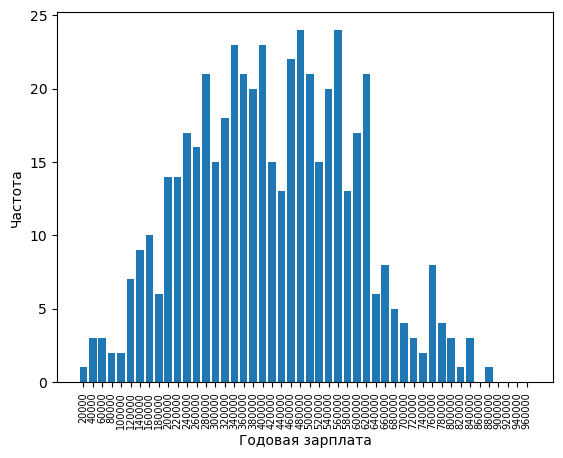

In [122]:
plt.bar(net_worth_grouped_origin.index, net_worth_grouped_origin.values)
plt.xlabel("Годовая зарплата")
plt.ylabel("Частота")
plt.xticks(rotation=90, fontsize=7)
plt.show()

Car Purchase Amount Тут надо отметить, что распределение данных чисто визуально сильно отличается от нормального распределения, дальше перейдём к последнему числовому полю Car Purchase Amount. Проделамем те же действия: разделим на опредлённые подкатегории и построим гистограмму. 

In [123]:
car_purchase_amount_origin = ds_original["Car Purchase Amount"].value_counts()
car_purchase_amount_origin = car_purchase_amount_origin.sort_index()
car_purchase_amount_origin

Car Purchase Amount
9000.00000     1
10092.22509    1
12536.93842    1
12895.71468    1
17584.56963    1
              ..
68925.09447    1
69669.47402    1
70598.96768    1
70878.29664    1
80000.00000    1
Name: count, Length: 500, dtype: int64

In [124]:
a = 2000
bins = range(9000, 80000, a)
labels = [str(x) for x in bins[:-1]]
car_purchase_amount_groped_origin =  pd.cut(car_purchase_amount_origin.index, bins=bins, labels=labels).value_counts()

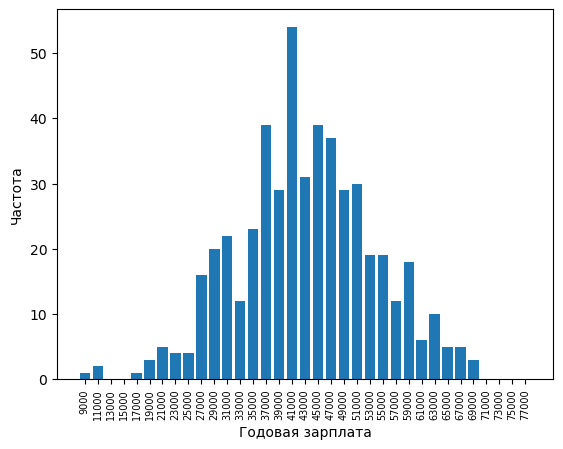

In [125]:
plt.bar(car_purchase_amount_groped_origin.index, car_purchase_amount_groped_origin.values)
plt.xlabel("Годовая зарплата")
plt.ylabel("Частота")
plt.xticks(rotation=90, fontsize=7)
plt.show()

Тут видно, что распределение может напоминать нормальное, однако сумма в районе 41000 сильно выбивается вперёд.

Вообще если делать общие выводы, то можно сказать, что выбросов нигде не наблюдается и в среднем распределение стремится к нормальному.

Двумерная визуализация данных
-

Далее перейдём к анализу полей относительно поля Car Purchase Amount для выявления связей между этими приизнаками и Car Purchase Amount.

<Axes: >

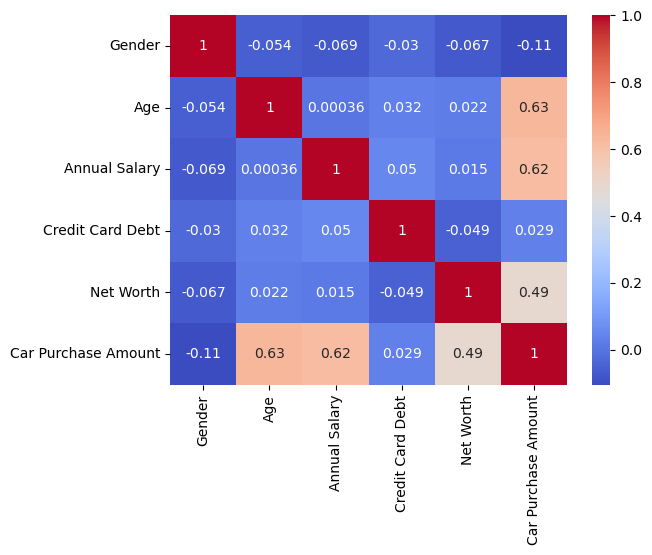

In [126]:
numeric_cols = ["Gender", "Age", "Annual Salary", "Credit Card Debt", "Net Worth","Car Purchase Amount"]
corr_matrix = ds_original[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm')

Тут мы можем видеть, что с Car Purchase Amount лучше всего коррелируют Age, Annual Salary и немного коррелирует NetWorth. Чтобы убедится в этом, построю матрицу диаграммы рассеяния.

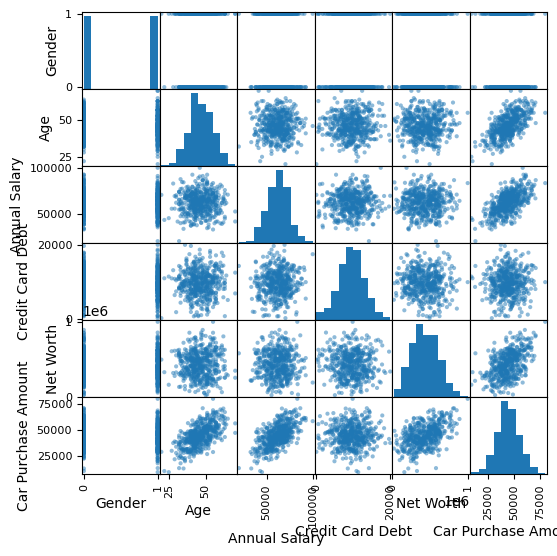

In [127]:
scatter_matrix(ds_original[numeric_cols], figsize=(6,6))
plt.show()

Тут мы тоже можем видеть, что Car Purchase Amout зависит  от Age, Annual Salary и Net Worth. Так что моё предположение верно. Credit Card Dept и Car Purchase не похоже, что связаны хоть как-то , также как и с Gender(там вообще сложно говорить о какой-то связи , так как данные распределены равномерно и являются бинарными). Про Credit Card Dept можно только сказать, что наибольшее число значений сконцентрировано именно в середине значений , но сомневаюсь, что это может говорить о какой-то функциональной зависимости, тем более, что карта корреляции это подтверждает.

Линейная регрессия
-

Сейчас разделим выборку для данных на обучающую, контрольную и тестовую

In [128]:
ds_original_learn, ds_original_control = train_test_split(ds_original, test_size=0.2)
ds_original_control, ds_original_test = train_test_split(ds_original_control, test_size= 0.5)

Теперь выделим от сюда X и Y, в качестве Y будут выступать значения столбца Car Purchase Amount , в качестве параметров X выступают столбцы Age, Annual Salary, Credit Card Debt, Net Worth

In [129]:
Y_original_learn = ds_original_learn["Car Purchase Amount"]
Y_original_control = ds_original_control["Car Purchase Amount"]
Y_original_test = ds_original_test["Car Purchase Amount"]

X_original_learn = ds_original_learn[["Age","Annual Salary", "Credit Card Debt", "Net Worth"]]
X_original_control = ds_original_control[["Age","Annual Salary", "Credit Card Debt", "Net Worth"]]
X_original_test = ds_original_test[["Age","Annual Salary", "Credit Card Debt", "Net Worth"]]

Перейдём к обучению модели и выводе метрик, также возможно придётся подбирать значения alpha

In [130]:
model_lasso = Lasso(alpha=0.5)
model_lasso.fit(X= X_original_learn, y=Y_original_learn)

y_pred_learn = model_lasso.predict(X_original_learn)

model_r2_learn_original = r2_score(Y_original_learn, y_pred_learn)
model_MSE_learn_original = np.sqrt( mean_squared_error(Y_original_learn, y_pred_learn))

print("RMSE on learning: ", model_MSE_learn_original )
print("R2 on learning: ", model_r2_learn_original)

RMSE on learning:  241.52836711679535
R2 on learning:  0.9995137576594356


Мы можем видеть крайне интересную картину, у нас крайне высокая R2 метрика, но при этом плохая MSE, можно сделать ряд предположений почему это так, но я предпочту в начале сделать проверку на контрольных значениях

In [131]:
y_pred_control = model_lasso.predict(X_original_control)

model_r2_learn_control = r2_score(Y_original_control, y_pred_control)
model_MSE_learn_control = np.sqrt(mean_squared_error(Y_original_control, y_pred_control))

print("RMSE on learning: ", model_MSE_learn_control )
print("R2 on learning: ", model_r2_learn_control)

RMSE on learning:  238.31422323979055
R2 on learning:  0.9990672351744179


Тут мы видим аналогичную ситуацию, выведу коэффициенты и свободный член

In [132]:
print(model_lasso.coef_)
print(model_lasso.intercept_)

[8.39717880e+02 5.62341403e-01 5.80173926e-03 2.89267435e-02]
-42086.90171034451


Тут стоит вспомнить в чём состоит Lasso регрессия. Она обнуляет наименьшие веса (ну или пытается обнулить) и тут всплывает проблема немасштабируемых данных исходного датасета. В нём очень большой разброс значений, например Annual Salary принимает значение [20000:100000], а Credit Card Debt [299824.195900:1000000.000000]. Проблема заключается в том, что Lasso регрессия чувствительна к масштабируемым данным (они должны быть таковыми). Из-за этого возникает такая разница в коэффициентах (839, 0.5, 0.003, 0.02). Ведь, несмотря на то, что имеется не одно хорошо коррелирующее значение, коэффициент значительный только 1. Из-за этого же возникает и проблема с RMSE.

Не стоит забывать, что мы используем в обучении параметры, которые плохо коррелиируют, что также может влиять

Я бы сказал, что в данном случае Lasso регресиия не очень подходит, посмотрим потом как она поведёт себя на масштабтрованных данных.

Полиномиальная регрессия 
-

Теперь попробуем использовать полиномиальную модель. Для базового теста предлагаю использовать полином 4 степени, так как признака 4, потом рассмотрим и другие

In [133]:
poly = PolynomialFeatures(degree=4)

X_original_learn_poly = poly.fit_transform(X_original_learn)
X_original_control_poly = poly.fit_transform(X_original_control)


In [134]:
model = LinearRegression()

model.fit(X_original_learn_poly,Y_original_learn)

y_pred_learn_poly = model.predict(X_original_learn_poly)

model_RMSE_learn_original_poly = np.sqrt(mean_squared_error(Y_original_learn, y_pred_learn_poly))
model_R2_learn_original_poly = r2_score(Y_original_learn, y_pred_learn_poly)

print("RMSE on learning poly: ", model_RMSE_learn_original_poly)
print("R2 on learning poly: ", model_R2_learn_original_poly)

RMSE on learning poly:  1147.524778768441
R2 on learning poly:  0.9890240877325982


Хочется прервать поток кода, тут данные выглядят более многообещающими , нет гиперреалистичного R2, так что предлагаю перейти к перебору разных степеней полинома(начиная с 2 и до 6). Единственное, заметна проблема с RMSE - она очень большая 

In [135]:
degrees = [1,2,3,4,5,6]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_original_learn_poly = poly.fit_transform(X_original_learn)
    
    model = LinearRegression()
    model.fit(X_original_learn_poly, Y_original_learn)
    y_pred_learn_poly = model.predict(X_original_learn_poly)
    
    model_RMSE_learn_original_poly = np.sqrt(mean_squared_error(Y_original_learn, y_pred_learn_poly))
    model_R2_learn_original_poly = r2_score(Y_original_learn, y_pred_learn_poly)

    results_rmse.append(model_RMSE_learn_original_poly)
    results_r2.append(model_R2_learn_original_poly)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ", model_RMSE_learn_original_poly)
    print("R2: ", model_R2_learn_original_poly)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)



Degree:  1
RMSE:  241.52835875048646
R2:  0.9995137576931215
Degree:  2
RMSE:  239.16562974858033
R2:  0.9995232244033947
Degree:  3
RMSE:  346.29349553356593
R2:  0.9990004485553834
Degree:  4
RMSE:  1147.524778768441
R2:  0.9890240877325982
Degree:  5
RMSE:  1751.8958826207
R2:  0.9744180841173139
Degree:  6
RMSE:  2395.839437953347
R2:  0.9521555130540122
Names:  [1, 2, 3, 4, 5, 6]
RMSE:  [np.float64(241.52835875048646), np.float64(239.16562974858033), np.float64(346.29349553356593), np.float64(1147.524778768441), np.float64(1751.8958826207), np.float64(2395.839437953347)]
R2:  [0.9995137576931215, 0.9995232244033947, 0.9990004485553834, 0.9890240877325982, 0.9744180841173139, 0.9521555130540122]


Визуализируем полученные данные

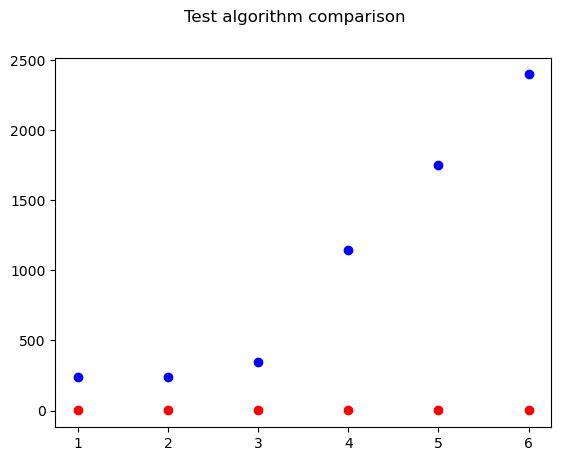

In [136]:
plt.plot(names, results_rmse, "bo")
plt.plot(names, results_r2, "ro")
plt.suptitle("Test algorithm comparison")
plt.show()

Тут видно, что лучше всего себя показывает полином со степенью 2, ведь после него RMSE уходит куда-то в небеса.
Теперь перейдём к тестам на контрольной выборке.

In [137]:
degrees = [1,2,3,4,5,6]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_original_learn_poly = poly.fit_transform(X_original_learn)
    X_original_control_poly = poly.fit_transform(X_original_control)
    model = LinearRegression()
    model.fit(X_original_learn_poly, Y_original_learn)
    y_pred_сontrol_poly = model.predict(X_original_control_poly)
    
    model_RMSE_learn_original_poly = np.sqrt(mean_squared_error(Y_original_control, y_pred_сontrol_poly))
    model_R2_learn_original_poly = r2_score(Y_original_control, y_pred_сontrol_poly)

    results_rmse.append(model_RMSE_learn_original_poly)
    results_r2.append(model_R2_learn_original_poly)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ", model_RMSE_learn_original_poly)
    print("R2: ", model_R2_learn_original_poly)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)


Degree:  1
RMSE:  238.3018814248739
R2:  0.9990673317839495
Degree:  2
RMSE:  238.39605496054642
R2:  0.9990665944836974
Degree:  3
RMSE:  277.01565228714287
R2:  0.9987396799301899
Degree:  4
RMSE:  795.597607323435
R2:  0.9896041699453811
Degree:  5
RMSE:  1262.22026181655
R2:  0.9738336871629696
Degree:  6
RMSE:  1769.7153831410938
R2:  0.9485625907281262
Names:  [1, 2, 3, 4, 5, 6]
RMSE:  [np.float64(238.3018814248739), np.float64(238.39605496054642), np.float64(277.01565228714287), np.float64(795.597607323435), np.float64(1262.22026181655), np.float64(1769.7153831410938)]
R2:  [0.9990673317839495, 0.9990665944836974, 0.9987396799301899, 0.9896041699453811, 0.9738336871629696, 0.9485625907281262]


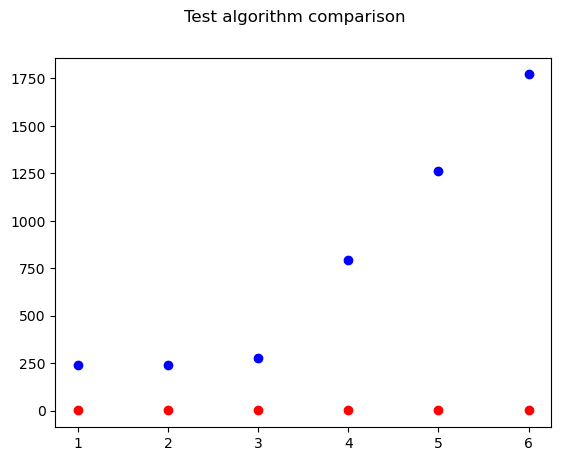

In [138]:
plt.plot(names, results_rmse, "bo")
plt.plot(names, results_r2, "ro")
plt.suptitle("Test algorithm comparison")
plt.show()

Тут мы можем видеть, что лучшей степенью является 1, но мы её брать не будем, ведь стпень 1 - это прямая , так что следующая лучшая степень - это 2, ведь после 3 степени RMSE резко начинает увеличиваться, так что я остановлюсь на этом.

Теперь надо привести равнение метрик для линейной модели и полиномиальной модели.

In [139]:
linear_rmse_origin = 241.52836711679535
linear_r2_origin = 0.9990672351744179

poly_rmse_origin = 238.39605496054642
poly_r2_origin = 0.9990665944836974

print(linear_rmse_origin-poly_rmse_origin, linear_r2_origin - poly_r2_origin)

3.132312156248929 6.406907204770107e-07


Тут можно увидеть, что полиномиальная модель со степенью полинома 2 подходит лучше. Я бы обозначил несколько проблем в текущем датасете, которые стоит учитывать при оценке:
+ Данные не масштабируемые, а это может сильно влиять на Lasso регрессию
+ В обучении модели использовались признаки, которые слабо коррелируют с целевым признаком
+ Часть потенциально полезных признаков пока не сущетсвует, потому что нелььзя менять и добавлять признаки

Работа с исходными масштабированными данными
=

Работа с построенными данными
=

Работа с построенными масштабированными данными
=